In [1]:
import json
import plotly.express as px
import pandas as pd
# import openpyxl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Tender schedule with starting point

In [55]:
with open('Deterministic_results_F_Q_I_S_MMR_Penta_as_antigen.json') as json_file:
    F_results = json.load(json_file)


In [56]:

# List of keywords to search for
keywords_to_search = ["M"]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})


In [57]:
# List of keywords to search for
keywords_to_search2 = ["X", "F"]

# Initialize a dictionary to store grouped results
grouped_results2 = {keyword: [] for keyword in keywords_to_search2}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search2:
        if keyword in key:
            grouped_results2[keyword].append({key: value})

In [58]:
#filter for F and X, to show vaccines allocated per tender

# Extract the 'M' group
m_group = grouped_results.get('M', [])

# Filter dictionaries starting with 'X' or 'F' and exclude those with 'X_tilde'
filtered_dicts = [
    entry for entry in m_group
    if any((key.startswith(('X[', 'F')) and 'X_tilde' not in key) for key in entry)
       and not all(value == 0 for key, value in entry.items())
       and all('HPV' not in key for key in entry)
]

In [59]:
#filter for F and X, to show vaccines allocated per tender

# Extract the 'M' group
X_group = grouped_results2.get('X', [])

# Filter dictionaries starting with 'X' or 'F' and exclude those with 'X_tilde'
filtered_dicts2 = [
    entry for entry in X_group
    if any((key.startswith(('X[')) and 'X_tilde' not in key) for key in entry)
       and not all(value == 0 for key, value in entry.items())
       # and all('HPV' not in key for key in entry)
]

In [60]:
#group the data into X and F

# Function to group items by key start value
def group_by_start_value(items):
    grouped_data = {}

    for item in items:
        key = list(item.keys())[0]  # Extract the key from the dictionary
        start_value = key[0]  # Get the first character of the key
        if start_value not in grouped_data:
            grouped_data[start_value] = []
        grouped_data[start_value].append(item)

    return grouped_data

# Group the data
result = group_by_start_value(filtered_dicts)

result


{'F': [{'F[Measles,(31, 35)]': 1.0},
  {'F[Mumps,(11, 15)]': 1.0},
  {'F[Mumps,(31, 35)]': 1.0},
  {'F[Measles,(1, 3)]': 1.0},
  {'F[Measles,(6, 10)]': 1.0},
  {'F[MMR,(16, 20)]': 1.0},
  {'F[MMR,(26, 30)]': 1.0},
  {'F[MMR,(1, 5)]': 1.0},
  {'F[MMR,(31, 35)]': 1.0},
  {'F[Measles,(21, 25)]': 1.0},
  {'F[Mumps,(26, 30)]': 1.0},
  {'F[MMR,(21, 25)]': 1.0},
  {'F[Mumps,(1, 3)]': 1.0},
  {'F[Mumps,(21, 25)]': 1.0},
  {'F[MMR,(11, 15)]': 1.0},
  {'F[Measles,(16, 20)]': 1.0},
  {'F[Measles,(26, 30)]': 1.0},
  {'F[Measles,(11, 15)]': 1.0},
  {'F[MMR,(6, 10)]': 1.0},
  {'F[Mumps,(4, 8)]': 1.0},
  {'F[Mumps,(6, 10)]': 1.0},
  {'F[Measles,(2, 6)]': 1.0},
  {'F[Mumps,(16, 20)]': 1.0}],
 'X': [{'X[MMR,Serum_Institute,31]': 558506141.8356833},
  {'X[MMR,Serum_Institute,34]': 468997467.7726883},
  {'X[MMR,Merck_Sharp,1]': 3100000.0},
  {'X[MMR,Serum_Institute,25]': 434480414.8303746},
  {'X[MMR,Serum_Institute,33]': 530825881.16285884},
  {'X[MMR,Serum_Institute,14]': 347543654.8675726},
  {'X[MMR,

In [61]:
#group the data into X and F

# Function to group items by key start value
def group_by_start_value(items):
    grouped_data = {}

    for item in items:
        key = list(item.keys())[0]  # Extract the key from the dictionary
        start_value = key[0]  # Get the first character of the key
        if start_value not in grouped_data:
            grouped_data[start_value] = []
        grouped_data[start_value].append(item)

    return grouped_data

# Group the data
result2 = group_by_start_value(filtered_dicts2)

# result2

In [62]:
# create dictionary from F data from above
# Extracting information from the dictionary
data_list = []
for item in result['F']:
    key, value = list(item.items())[0]
    # print(key)
    tender = key.split('[', 1)[1].split(',', 1)[0]
    start, finish = eval(key.split('(', 1)[1].split(')', 1)[0])
    value = item[key]
    
    data_list.append({'Tender': tender, 'Start': start, 'Finish': finish, 'Value': value})

# Create a DataFrame
F_values_df = pd.DataFrame(data_list)
F_values_df = F_values_df[F_values_df.Tender == 'Measles']
F_values_df.Start = F_values_df.Start -1
# Display the DataFrame
F_values_df


,Tender,Start,Finish,Value
0,Measles,30,35,1.0
3,Measles,0,3,1.0
4,Measles,5,10,1.0
9,Measles,20,25,1.0
15,Measles,15,20,1.0
16,Measles,25,30,1.0
17,Measles,10,15,1.0
21,Measles,1,6,1.0


In [63]:

# Extracting data for the DataFrame
df_data = []
for entry in result['X']:
    key, value = entry.popitem()
    vaccine = key.split(',')[0][2:]
    producer = key.split(',')[1].strip()
    start = int(key.split(',')[2].split(']')[0])
    end = int(start)
    df_data.append({'Vaccine': vaccine, 'Producer': producer, 'Start': start, 'End': end, 'Value': value})

# Creating DataFrame
X_data = pd.DataFrame(df_data)

# Print the DataFrame
X_data.head()


,Vaccine,Producer,Start,End,Value
0,MMR,Serum_Institute,31,31,5.585061e+08
1,MMR,Serum_Institute,34,34,4.689975e+08
2,MMR,Merck_Sharp,1,1,3.100000e+06
3,MMR,Serum_Institute,25,25,4.344804e+08
4,MMR,Serum_Institute,33,33,5.308259e+08


In [64]:

# Extracting data for the DataFrame
df2_data = []
for entry in result2['X']:
    key, value = entry.popitem()
    vaccine = key.split(',')[0][2:]
    producer = key.split(',')[1].strip()
    start = int(key.split(',')[2].split(']')[0])
    end = int(start)
    df2_data.append({'Vaccine': vaccine, 'Producer': producer, 'Start': start, 'End': end, 'Value': value})

# Creating DataFrame
X_data_penta = pd.DataFrame(df2_data)

Vaccines_to_keep = ['Penta','TT', 'Td', 'DT','DTwP','HepB', 'DTwP-Hib', 'OPV', 'IPV']
X_data_penta = X_data_penta[X_data_penta['Vaccine'].isin(Vaccines_to_keep)]

# Print the DataFrame
X_data_penta


,Vaccine,Producer,Start,End,Value
0,Penta,Serum_Institute,16,16,1.983108e+08
4,OPV,Bharat_Biotech,3,3,3.366389e+07
5,Penta,Serum_Institute,2,2,5.838054e+08
6,OPV,Panacea_Biotec,18,18,2.050000e+06
7,OPV,Beijing_Institute,26,26,8.200000e+06
...,...,...,...,...,...
573,OPV,Panacea_Biotec,1,1,1.360196e+07
576,TT,BB_NCIPD,19,19,1.965091e-07
578,Penta,PT_Bio,13,13,1.229625e+08
579,OPV,Serum_Institute,8,8,1.100500e+08


In [65]:
X_data_penta.Producer.unique()


array(['Serum_Institute', 'Bharat_Biotech', 'Panacea_Biotec',
       'Beijing_Institute', 'LG_Chem', 'Biological_E', 'BB_NCIPD',
       'PT_Bio', 'Haffkine_Bio', 'AJ_Vaccines', 'Bilthoven', 'GSK'],
      dtype=object)

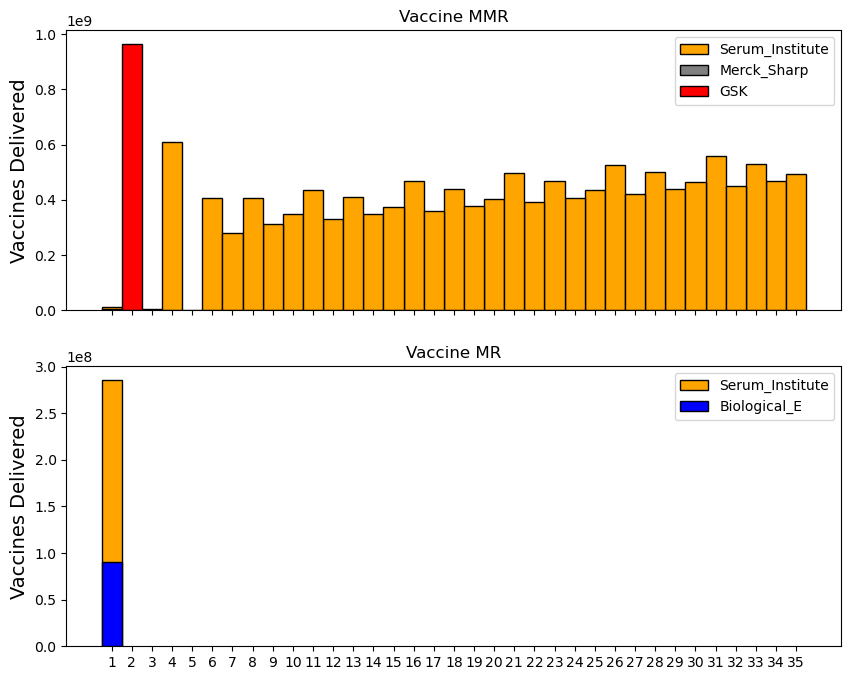

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Using DataFrame.insert() to add a column
# F_values_df.insert(2, "Color", ['green', 'blue', 'orange', 'red', 'grey', 'purple','yellow','maroon'], True)

# Create subplots for each vaccine
fig, axs = plt.subplots(nrows=len(X_data['Vaccine'].unique()), figsize=(10, 8), sharex=True)

# Define unique colors for each producer
producer_colors = {'Biological_E': 'blue', 'Serum_Institute': 'orange', 'PT_Bio': 'green', 'GSK': 'red', 'Merck_Sharp':'grey'}

# Plot stacked bars for each vaccine
for i, (vaccine, group) in enumerate(X_data.groupby('Vaccine')):
    producers = group['Producer'].unique()
    
    for producer in producers:
        producer_data = group[group['Producer'] == producer]
        axs[i].bar(producer_data['Start'], producer_data['Value'], label=producer, bottom=np.zeros(len(producer_data)), width=1.0, edgecolor='black', linewidth=1, color=producer_colors.get(producer, 'gray'))

    axs[i].set_title(f'Vaccine {vaccine}')
    axs[i].set_ylabel('Vaccines Delivered', fontsize=14)
    axs[i].legend()
    


# Set x-axis ticks for each year
for ax in axs.flat:
    ax.set_xticks(np.arange(min(X_data['Start']), max(X_data['End']) + 1, 1))
    # ax.set_xlabel('Time (Start)')


# plt.suptitle('Measles vaccination by Vaccine/Producer')
plt.savefig('Deterministic_results_F_Q_I_S_30_with_mod_MMR.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


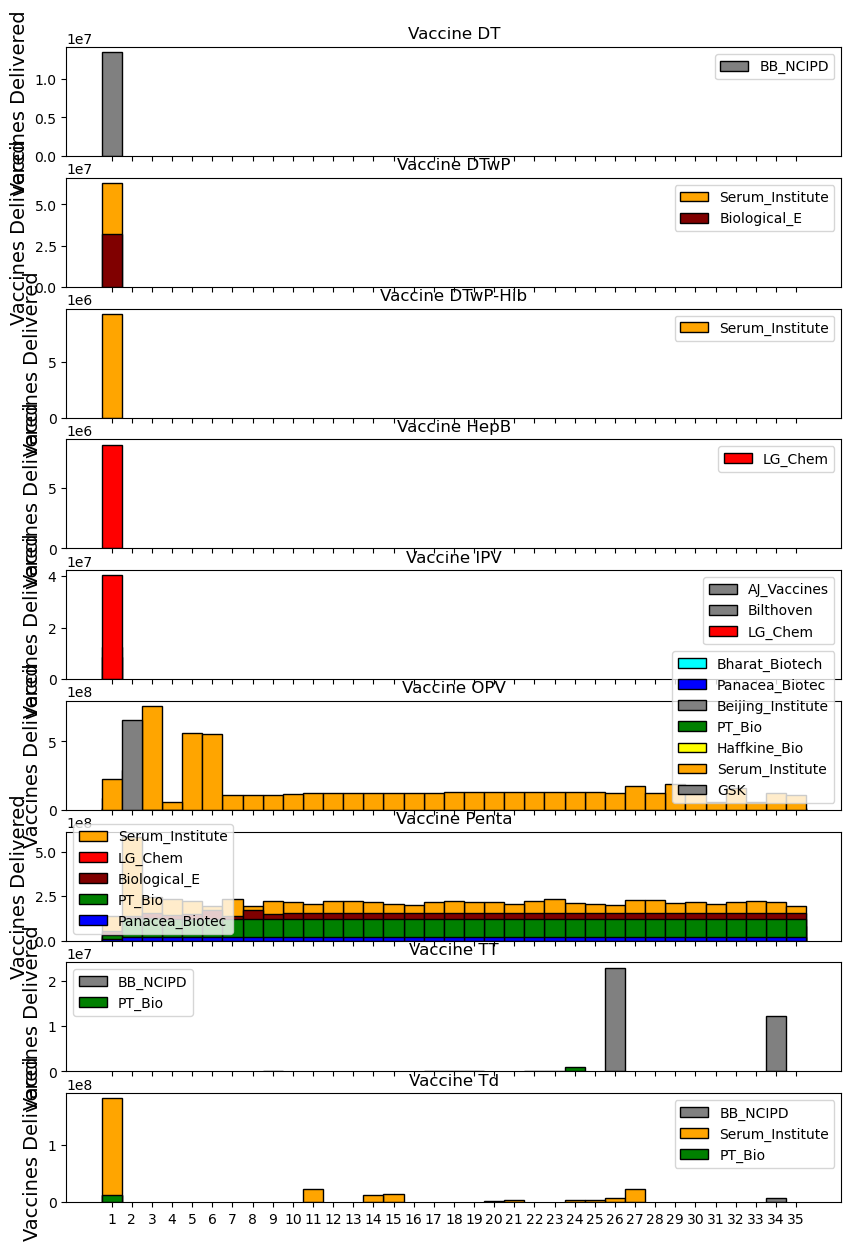

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Using DataFrame.insert() to add a column
# F_values_df.insert(2, "Color", ['green', 'blue', 'orange', 'red', 'grey', 'purple','yellow','maroon'], True)

# Create subplots for each vaccine
fig, axs = plt.subplots(nrows=len(X_data_penta['Vaccine'].unique()), figsize=(10, 15), sharex=True)

# Define unique colors for each producer
producer_colors = {'Panacea_Biotec': 'blue', 'Serum_Institute': 'orange',
                   'PT_Bio': 'green', 'Haffkine_Bio': 'yellow', 'Bharat_Biotech':'cyan',
                   'LG_Chem': 'red', 'BB_NCIPD':'grey', 'Biological_E':'maroon'}

# Plot stacked bars for each vaccine
for i, (vaccine, group) in enumerate(X_data_penta.groupby('Vaccine')):
    producers = group['Producer'].unique()
    
    for producer in producers:
        producer_data = group[group['Producer'] == producer]
        axs[i].bar(producer_data['Start'], producer_data['Value'], label=producer, bottom=np.zeros(len(producer_data)), width=1.0, edgecolor='black', linewidth=1, color=producer_colors.get(producer, 'gray'))

    axs[i].set_title(f'Vaccine {vaccine}')
    axs[i].set_ylabel('Vaccines Delivered', fontsize=14)
    axs[i].legend()
    


# Set x-axis ticks for each year
for ax in axs.flat:
    ax.set_xticks(np.arange(min(X_data_penta['Start']), max(X_data_penta['End']) + 1, 1))
    # ax.set_xlabel('Time (Start)')


# plt.suptitle('Measles vaccination by Vaccine/Producer')
plt.savefig('Deterministic_results_F_Q_I_S_30_with_mod_Penta.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

In [68]:
# X_data = X_data[X_data.Vaccine == "MMR"].copy()
# X_data.to_csv('MR_data2.csv', index=False)

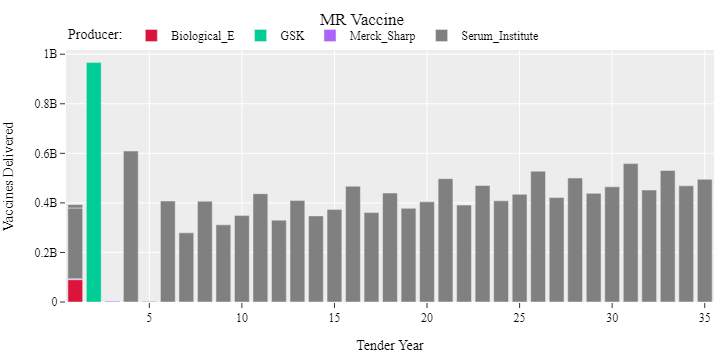

In [69]:
X_data.sort_values(by=["Producer"], inplace=True)
fig = px.bar(X_data, x="Start", y="Value", color="Producer", title="MR Vaccine", color_discrete_map={"Serum_Institute": "grey", "Biological_E": "crimson"},)
fig.update_layout(
    font=dict(family="CMU Serif", size=12, color="black"),
    margin=dict(l=50, r=10, b=50, t=50, pad=0),
    template="ggplot2",
    height=300,
    width=800,
    xaxis=dict(title="Tender Year"),
    yaxis=dict(title="Vaccines Delivered"),
    legend=dict(title="Producer:", orientation="h", yanchor="bottom", x=0, y=1.0, xanchor="left"),
)
fig.show()

fig.write_image("MR_data.png", scale=4)